# Protein PTM Prediction - Data Exploration

This notebook explores the training data for multi-label post-translational modification prediction.

**Task:** Predict three cysteine-related modifications:
- S-glutathionylation
- S-nitrosylation
- S-palmitoylation

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [22]:
# Load training data
df = pd.read_csv('../data/train.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total sequences: {len(df):,}")
print("\nFirst few rows:")
df.head()

Dataset shape: (89010, 5)
Total sequences: 89,010

First few rows:


,ID,Sequence,S-glutathionylation,S-nitrosylation,S-palmitoylation
0,Q9H4H8,AAAAAAEDSFGSSHDCSSGTYFPEQSDLEPP,0,0,0
1,Q8N697,AAAAAAGAFAGRRAACGAVLLTELLERAAFY,0,1,0
2,Q8IP90,AAAAAAGKQIEGPEGCNLFIYHLPQEFTDTD,0,0,0
3,P36897,AAAAAALLPGATALQCFCHLCTKDNFTCVTD,0,0,0
4,Q8NCN4,AAAAAALSRRGRRGRCDETAAAKTGAPGPAS,0,0,0


In [23]:
# Data types and missing values
print("Data Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89010 entries, 0 to 89009
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   89010 non-null  object
 1   Sequence             89010 non-null  object
 2   S-glutathionylation  89010 non-null  int64 
 3   S-nitrosylation      89010 non-null  int64 
 4   S-palmitoylation     89010 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 3.4+ MB
None

Missing values:
ID                     0
Sequence               0
S-glutathionylation    0
S-nitrosylation        0
S-palmitoylation       0
dtype: int64


## 2. Basic Sequence Statistics

In [24]:
# Verify all sequences are 31 amino acids
df['seq_length'] = df['Sequence'].str.len()

print("Sequence length statistics:")
print(df['seq_length'].describe())
print(f"\nAll sequences length 31? {(df['seq_length'] == 31).all()}")

# Clean up
df.drop('seq_length', axis=1, inplace=True)

Sequence length statistics:
count    89010.0
mean        31.0
std          0.0
min         31.0
25%         31.0
50%         31.0
75%         31.0
max         31.0
Name: seq_length, dtype: float64

All sequences length 31? True


In [25]:
# Check for duplicate sequences
print(f"Total sequences: {len(df):,}")
print(f"Unique sequences: {df['Sequence'].nunique():,}")
print(f"Duplicate sequences: {len(df) - df['Sequence'].nunique():,}")

# Check if duplicates have same labels
duplicates = df[df.duplicated(subset=['Sequence'], keep=False)].sort_values('Sequence')
if len(duplicates) > 0:
    print("\nSample of duplicate sequences:")
    print(duplicates.head(10))

Total sequences: 89,010
Unique sequences: 89,010
Duplicate sequences: 0


## 3. Label Distribution Analysis

In [26]:
# Define label columns
label_cols = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']

# Distribution for each label
print("Individual Label Distribution:")
print("="*60)
for label in label_cols:
    counts = df[label].value_counts()
    total = len(df)
    print(f"\n{label}:")
    print(f"  Negative (0): {counts[0]:6,} ({counts[0]/total*100:5.2f}%)")
    print(f"  Positive (1): {counts[1]:6,} ({counts[1]/total*100:5.2f}%)")
    print(f"  Imbalance ratio: 1:{counts[0]/counts[1]:.2f}")

Individual Label Distribution:

S-glutathionylation:
  Negative (0): 84,271 (94.68%)
  Positive (1):  4,739 ( 5.32%)
  Imbalance ratio: 1:17.78

S-nitrosylation:
  Negative (0): 77,940 (87.56%)
  Positive (1): 11,070 (12.44%)
  Imbalance ratio: 1:7.04

S-palmitoylation:
  Negative (0): 85,701 (96.28%)
  Positive (1):  3,309 ( 3.72%)
  Imbalance ratio: 1:25.90


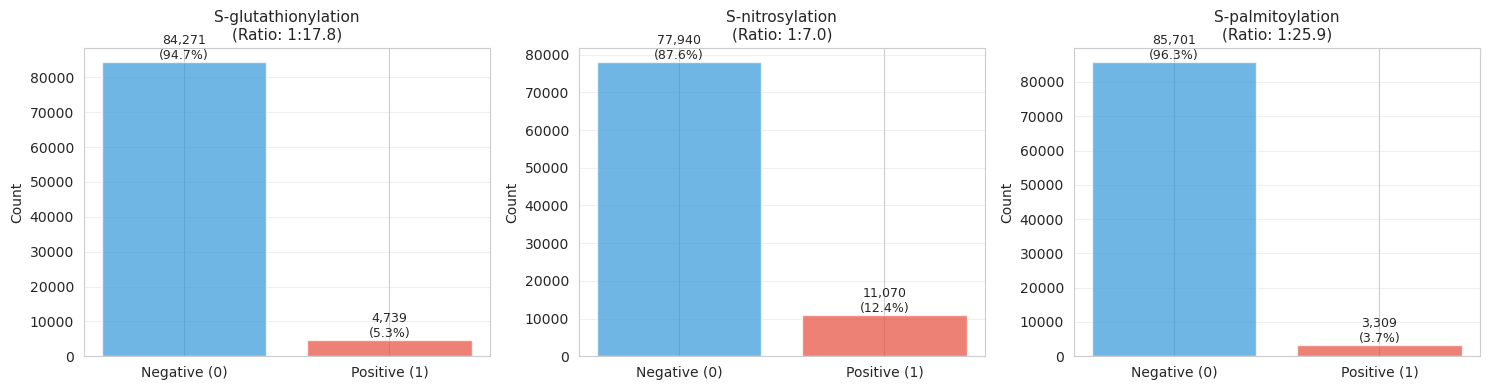

In [27]:
# Visualize label distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, label in enumerate(label_cols):
    counts = df[label].value_counts()
    axes[idx].bar(['Negative (0)', 'Positive (1)'], counts.values, 
                  color=['#3498db', '#e74c3c'], alpha=0.7)
    axes[idx].set_title(f'{label}\n(Ratio: 1:{counts[0]/counts[1]:.1f})', fontsize=11)
    axes[idx].set_ylabel('Count')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add count labels on bars
    for i, v in enumerate(counts.values):
        axes[idx].text(i, v, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                      ha='center', va='bottom', fontsize=9)

plt.tight_layout()
#plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#print("Saved: label_distribution.png")

## 4. Multi-Label Analysis

In [28]:
# Calculate total modifications per sequence
df['total_modifications'] = df[label_cols].sum(axis=1)

print("Number of modifications per sequence:")
print("="*60)
mod_counts = df['total_modifications'].value_counts().sort_index()
for n_mods, count in mod_counts.items():
    print(f"{n_mods} modifications: {count:6,} sequences ({count/len(df)*100:5.2f}%)")

print(f"\nSequences with NO modifications: {mod_counts[0]:,} ({mod_counts[0]/len(df)*100:.2f}%)")
print(f"Sequences with ANY modification: {df['total_modifications'].gt(0).sum():,} ({df['total_modifications'].gt(0).sum()/len(df)*100:.2f}%)")

Number of modifications per sequence:
0 modifications: 73,211 sequences (82.25%)
1 modifications: 13,092 sequences (14.71%)
2 modifications:  2,095 sequences ( 2.35%)
3 modifications:    612 sequences ( 0.69%)

Sequences with NO modifications: 73,211 (82.25%)
Sequences with ANY modification: 15,799 (17.75%)


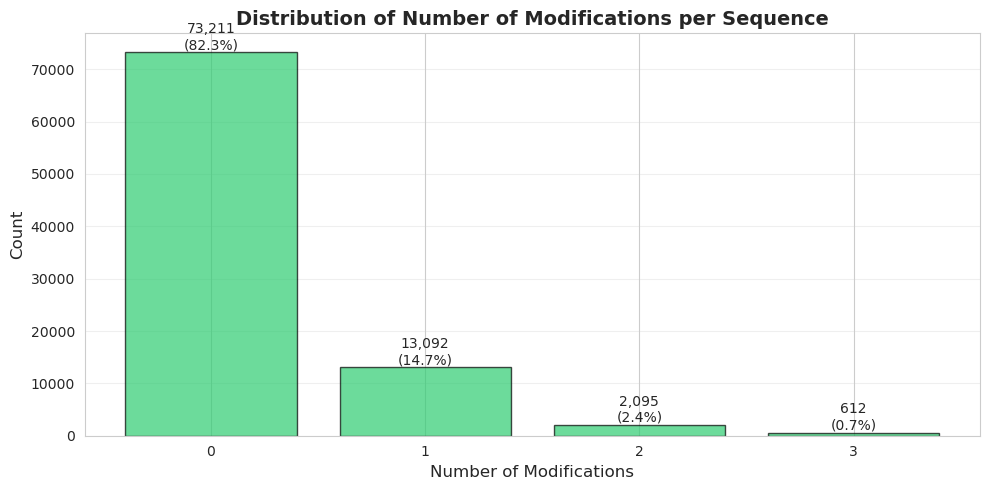

In [29]:
# Visualize modification counts
plt.figure(figsize=(10, 5))
bars = plt.bar(mod_counts.index, mod_counts.values, color='#2ecc71', alpha=0.7, edgecolor='black')
plt.xlabel('Number of Modifications', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Number of Modifications per Sequence', fontsize=14, fontweight='bold')
plt.xticks([0, 1, 2, 3])
plt.grid(axis='y', alpha=0.3)

# Add count labels
for i, (idx, v) in enumerate(mod_counts.items()):
    plt.text(idx, v, f'{v:,}\n({v/len(df)*100:.1f}%)', 
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
#plt.savefig('modification_counts.png', dpi=300, bbox_inches='tight')
plt.show()

#print("Saved: modification_counts.png")

## 5. Label Co-occurrence Analysis

In [30]:
# Create label combination strings
df['label_combination'] = df[label_cols].apply(
    lambda row: ','.join([label_cols[i] for i in range(len(label_cols)) if row.iloc[i] == 1]) or 'None',
    axis=1
)

# Count combinations
print("Label Combinations:")
print("="*60)
combo_counts = df['label_combination'].value_counts()
for combo, count in combo_counts.items():
    print(f"{combo:50s}: {count:6,} ({count/len(df)*100:5.2f}%)")

Label Combinations:
None                                              : 73,211 (82.25%)
S-nitrosylation                                   :  8,552 ( 9.61%)
S-glutathionylation                               :  2,454 ( 2.76%)
S-palmitoylation                                  :  2,086 ( 2.34%)
S-glutathionylation,S-nitrosylation               :  1,484 ( 1.67%)
S-glutathionylation,S-nitrosylation,S-palmitoylation:    612 ( 0.69%)
S-nitrosylation,S-palmitoylation                  :    422 ( 0.47%)
S-glutathionylation,S-palmitoylation              :    189 ( 0.21%)


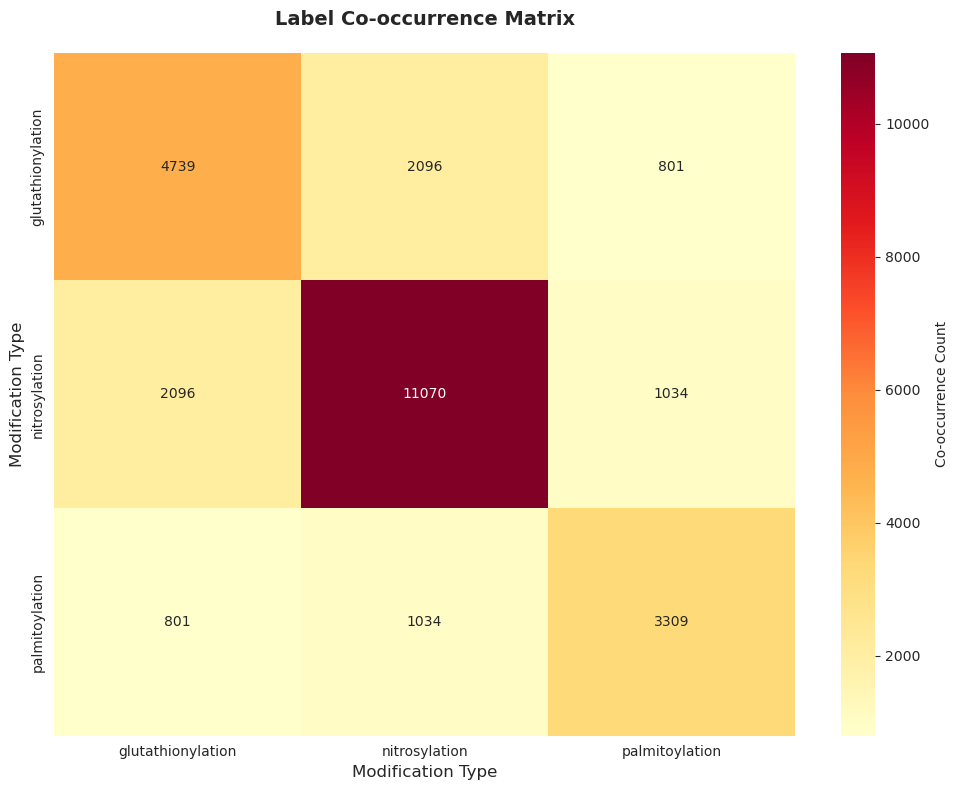

In [31]:
# Co-occurrence matrix
co_occurrence = np.zeros((3, 3))
for i, label1 in enumerate(label_cols):
    for j, label2 in enumerate(label_cols):
        co_occurrence[i, j] = ((df[label1] == 1) & (df[label2] == 1)).sum()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt='.0f', 
            xticklabels=[l.replace('S-', '') for l in label_cols],
            yticklabels=[l.replace('S-', '') for l in label_cols],
            cmap='YlOrRd', cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Label Co-occurrence Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Modification Type', fontsize=12)
plt.ylabel('Modification Type', fontsize=12)
plt.tight_layout()
#plt.savefig('cooccurrence_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

#print("Saved: cooccurrence_matrix.png")

## 6. Amino Acid Composition Analysis

In [32]:
# Standard amino acids
amino_acids = list('ACDEFGHIKLMNPQRSTVWY')

def get_aa_composition(sequence):
    """Calculate amino acid composition for a sequence."""
    counter = Counter(sequence)
    total = len(sequence)
    return {aa: counter.get(aa, 0) / total for aa in amino_acids}

# Calculate composition for all sequences
print("Calculating amino acid composition...")
aa_comp_list = df['Sequence'].apply(get_aa_composition)
aa_comp_df = pd.DataFrame(aa_comp_list.tolist())

print("\nOverall amino acid frequency (mean across all sequences):")
aa_freq = aa_comp_df.mean().sort_values(ascending=False)
print(aa_freq)

Calculating amino acid composition...

Overall amino acid frequency (mean across all sequences):
L    0.091019
S    0.072805
G    0.067031
C    0.066362
A    0.066234
E    0.063230
V    0.062778
P    0.054578
K    0.053956
T    0.052320
R    0.050434
D    0.050221
I    0.045943
Q    0.041197
N    0.039816
F    0.037104
Y    0.028320
H    0.025412
M    0.018960
W    0.012252
dtype: float64


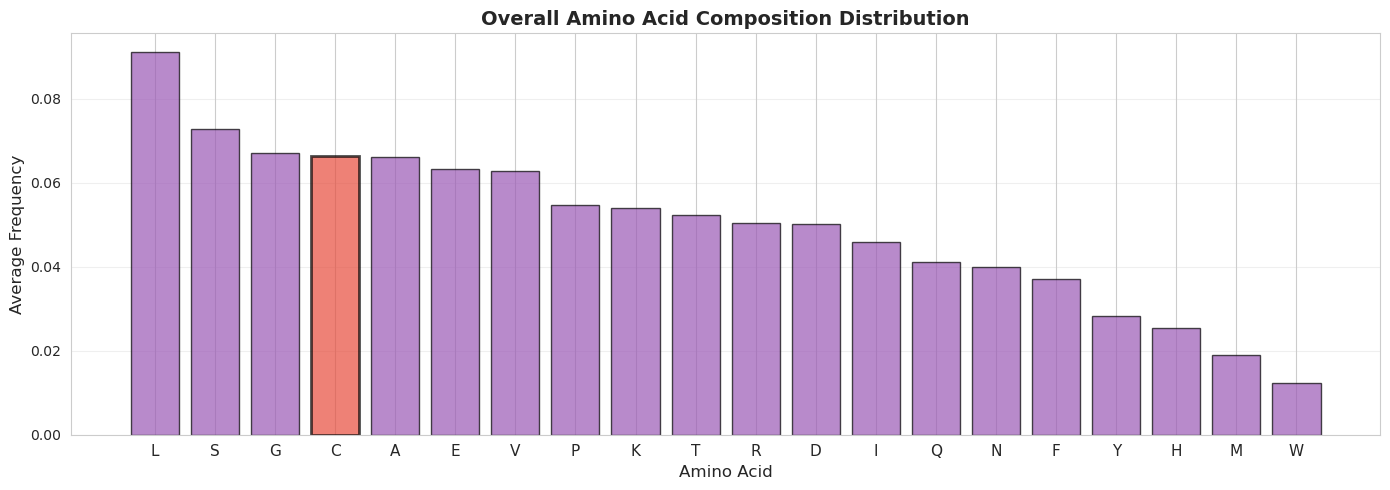


Note: Cysteine (C) frequency = 0.0664 (highlighted in red)


In [33]:
# Visualize overall amino acid distribution
plt.figure(figsize=(14, 5))
bars = plt.bar(range(len(aa_freq)), aa_freq.values, color='#9b59b6', alpha=0.7, edgecolor='black')
plt.xticks(range(len(aa_freq)), aa_freq.index, fontsize=11)
plt.xlabel('Amino Acid', fontsize=12)
plt.ylabel('Average Frequency', fontsize=12)
plt.title('Overall Amino Acid Composition Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Highlight cysteine (C) since modifications are cysteine-related
c_idx = list(aa_freq.index).index('C')
bars[c_idx].set_color('#e74c3c')
bars[c_idx].set_edgecolor('black')
bars[c_idx].set_linewidth(2)

plt.tight_layout()
#plt.savefig('aa_composition_overall.png', dpi=300, bbox_inches='tight')
plt.show()

#print("Saved: aa_composition_overall.png")
print(f"\nNote: Cysteine (C) frequency = {aa_freq['C']:.4f} (highlighted in red)")

In [34]:
# Compare AA composition between modified and non-modified sequences
print("Comparing amino acid composition: Modified vs Non-modified sequences")
print("="*80)

# Separate sequences
modified_mask = df['total_modifications'] > 0
aa_comp_modified = aa_comp_df[modified_mask].mean()
aa_comp_nonmodified = aa_comp_df[~modified_mask].mean()

# Calculate difference
aa_diff = aa_comp_modified - aa_comp_nonmodified
aa_diff_sorted = aa_diff.abs().sort_values(ascending=False)

print("\nTop 10 amino acids with largest composition difference:")
for aa in aa_diff_sorted.head(10).index:
    print(f"{aa}: Modified={aa_comp_modified[aa]:.4f}, "
          f"Non-modified={aa_comp_nonmodified[aa]:.4f}, "
          f"Diff={aa_diff[aa]:+.4f}")

Comparing amino acid composition: Modified vs Non-modified sequences

Top 10 amino acids with largest composition difference:
C: Modified=0.0520, Non-modified=0.0695, Diff=-0.0175
K: Modified=0.0672, Non-modified=0.0511, Diff=+0.0161
R: Modified=0.0580, Non-modified=0.0488, Diff=+0.0092
E: Modified=0.0697, Non-modified=0.0618, Diff=+0.0079
S: Modified=0.0680, Non-modified=0.0738, Diff=-0.0059
A: Modified=0.0708, Non-modified=0.0653, Diff=+0.0055
P: Modified=0.0502, Non-modified=0.0555, Diff=-0.0054
H: Modified=0.0213, Non-modified=0.0263, Diff=-0.0050
N: Modified=0.0374, Non-modified=0.0403, Diff=-0.0029
D: Modified=0.0525, Non-modified=0.0497, Diff=+0.0028


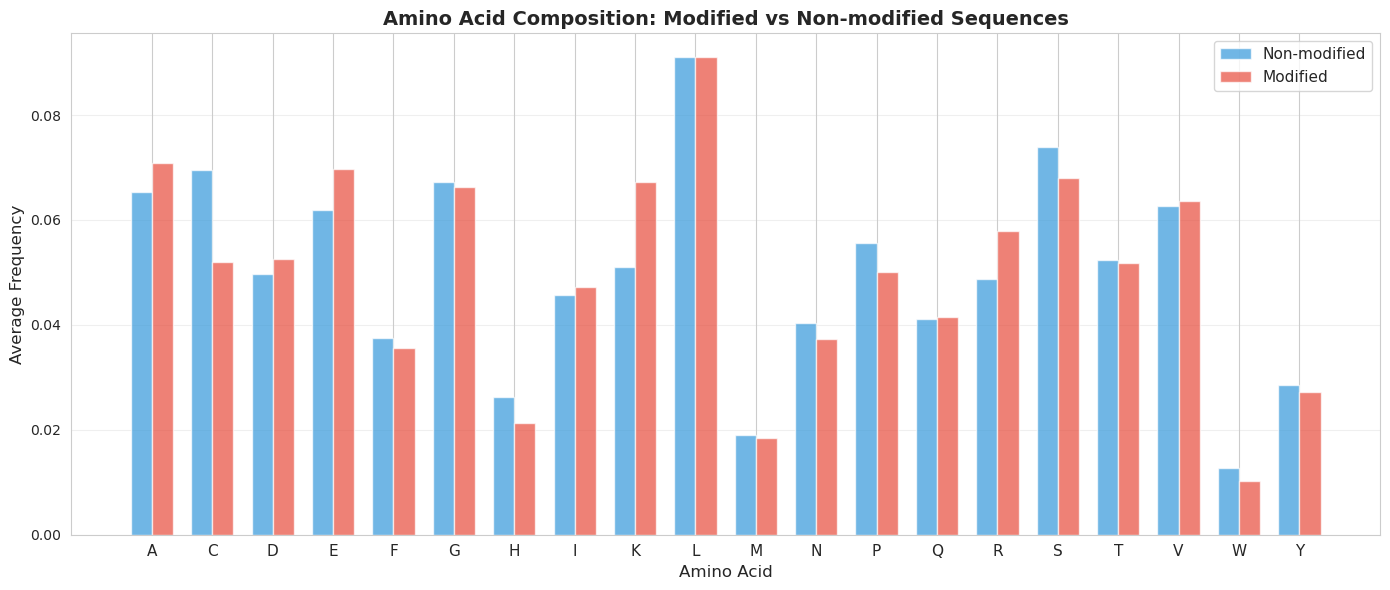

Saved: aa_composition_comparison.png


In [35]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(amino_acids))
width = 0.35

bars1 = ax.bar(x - width/2, aa_comp_nonmodified[amino_acids], width, 
               label='Non-modified', color='#3498db', alpha=0.7)
bars2 = ax.bar(x + width/2, aa_comp_modified[amino_acids], width, 
               label='Modified', color='#e74c3c', alpha=0.7)

ax.set_xlabel('Amino Acid', fontsize=12)
ax.set_ylabel('Average Frequency', fontsize=12)
ax.set_title('Amino Acid Composition: Modified vs Non-modified Sequences', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(amino_acids, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('aa_composition_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: aa_composition_comparison.png")

## 7. Position-Specific Analysis

In [36]:
# Analyze cysteine positions
def find_cysteine_positions(sequence):
    """Find positions of cysteine in sequence."""
    return [i for i, aa in enumerate(sequence) if aa == 'C']

df['cysteine_positions'] = df['Sequence'].apply(find_cysteine_positions)
df['num_cysteines'] = df['cysteine_positions'].apply(len)

print("Cysteine statistics:")
print(f"Sequences with at least one cysteine: {(df['num_cysteines'] > 0).sum():,} ({(df['num_cysteines'] > 0).sum()/len(df)*100:.2f}%)")
print(f"Sequences with no cysteine: {(df['num_cysteines'] == 0).sum():,} ({(df['num_cysteines'] == 0).sum()/len(df)*100:.2f}%)")
print("\nNumber of cysteines per sequence:")
print(df['num_cysteines'].value_counts().sort_index())

Cysteine statistics:
Sequences with at least one cysteine: 89,010 (100.00%)
Sequences with no cysteine: 0 (0.00%)

Number of cysteines per sequence:
num_cysteines
1     40529
2     25261
3     11022
4      5610
5      3975
6      2095
7       335
8        88
9        24
10       17
11        9
12       19
13       15
14       11
Name: count, dtype: int64


In [37]:
# Position-specific amino acid frequency (for position 15 - middle of sequence)
middle_pos = 15
print(f"\nAmino acid at position {middle_pos} (middle position):")
middle_aa = df['Sequence'].str[middle_pos].value_counts()
print(middle_aa)
print(f"\nCysteine at position {middle_pos}: {middle_aa.get('C', 0):,} sequences ({middle_aa.get('C', 0)/len(df)*100:.2f}%)")


Amino acid at position 15 (middle position):
Sequence
C    89010
Name: count, dtype: int64

Cysteine at position 15: 89,010 sequences (100.00%)


Creating position-specific amino acid heatmap...


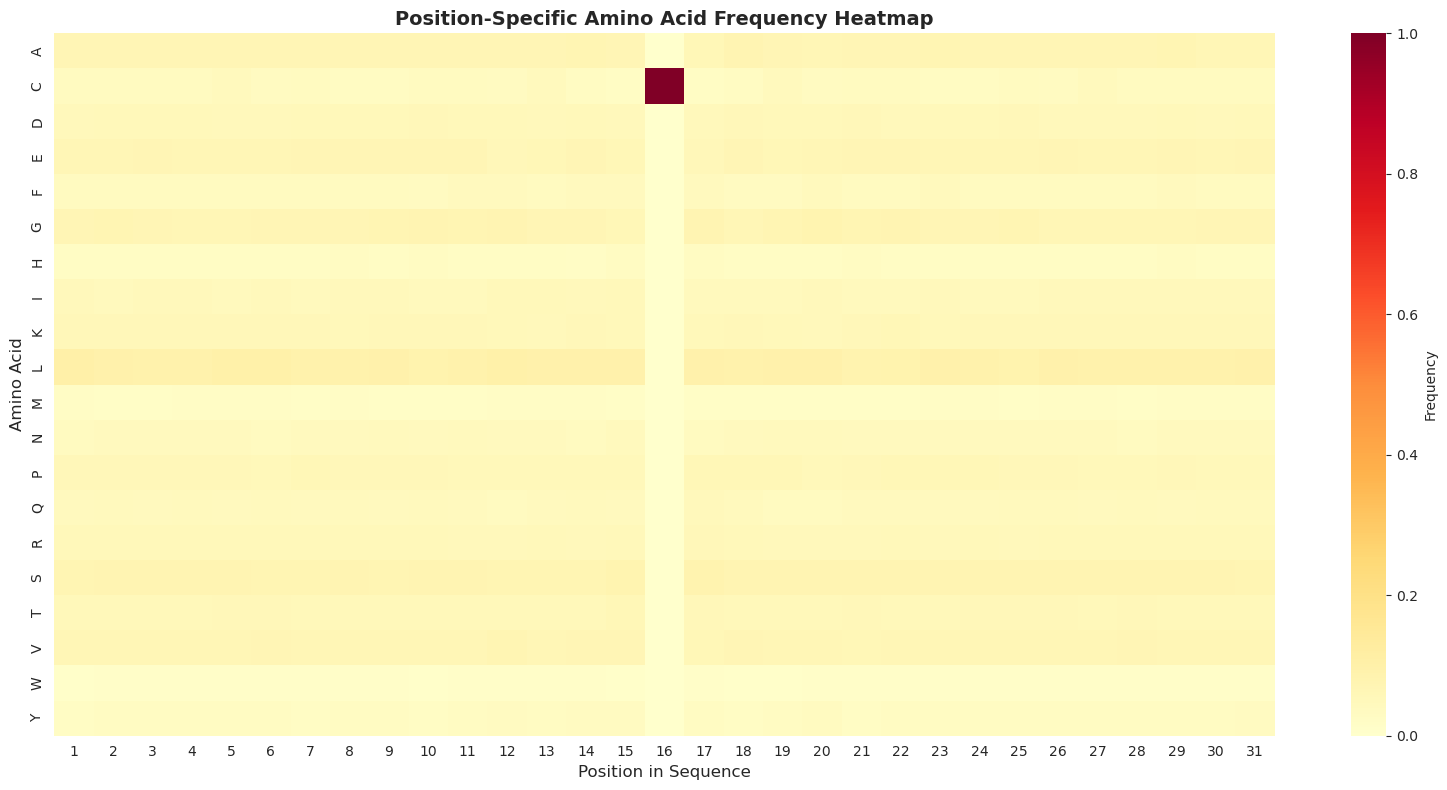

Saved: position_specific_heatmap.png


In [38]:
# Heatmap of amino acid positions
print("Creating position-specific amino acid heatmap...")

# Create position matrix
position_matrix = np.zeros((len(amino_acids), 31))
for pos in range(31):
    aa_at_pos = df['Sequence'].str[pos].value_counts()
    for aa_idx, aa in enumerate(amino_acids):
        position_matrix[aa_idx, pos] = aa_at_pos.get(aa, 0)

# Normalize by column
position_matrix_norm = position_matrix / position_matrix.sum(axis=0)

plt.figure(figsize=(16, 8))
sns.heatmap(position_matrix_norm, cmap='YlOrRd', 
            yticklabels=amino_acids, xticklabels=range(1, 32),
            cbar_kws={'label': 'Frequency'})
plt.xlabel('Position in Sequence', fontsize=12)
plt.ylabel('Amino Acid', fontsize=12)
plt.title('Position-Specific Amino Acid Frequency Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('position_specific_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: position_specific_heatmap.png")

## 8. Summary Statistics

In [39]:
print("="*80)
print("DATASET SUMMARY")
print("="*80)
print(f"\nTotal sequences: {len(df):,}")
print(f"Sequence length: 31 amino acids")
print(f"\nLabel distribution:")
for label in label_cols:
    pos_count = df[label].sum()
    print(f"  {label}: {pos_count:,} positive ({pos_count/len(df)*100:.2f}%)")

print(f"\nMulti-label statistics:")
print(f"  No modifications: {(df['total_modifications'] == 0).sum():,} ({(df['total_modifications'] == 0).sum()/len(df)*100:.2f}%)")
print(f"  1 modification: {(df['total_modifications'] == 1).sum():,} ({(df['total_modifications'] == 1).sum()/len(df)*100:.2f}%)")
print(f"  2 modifications: {(df['total_modifications'] == 2).sum():,} ({(df['total_modifications'] == 2).sum()/len(df)*100:.2f}%)")
print(f"  3 modifications: {(df['total_modifications'] == 3).sum():,} ({(df['total_modifications'] == 3).sum()/len(df)*100:.2f}%)")

print(f"\nCysteine statistics:")
print(f"  Sequences with cysteine: {(df['num_cysteines'] > 0).sum():,} ({(df['num_cysteines'] > 0).sum()/len(df)*100:.2f}%)")
print(f"  Average cysteines per sequence: {df['num_cysteines'].mean():.2f}")

print("\n" + "="*80)
print("KEY INSIGHTS FOR MODELING")
print("="*80)
print("1. SEVERE CLASS IMBALANCE: ~82% of sequences have no modifications")
print("   - Need to use class weighting, resampling, or focal loss")
print("   - Evaluation should focus on F1-score, not just accuracy")
print("\n2. MULTI-LABEL TASK: Sequences can have 0-3 modifications simultaneously")
print("   - Need multi-label classification approach (sigmoid + BCE loss)")
print("   - Cannot use softmax (assumes mutually exclusive classes)")
print("\n3. CYSTEINE-RELATED MODIFICATIONS: All three target modifications are on cysteine")
print("   - Position and context of cysteine residues are important features")
print("   - Consider extracting cysteine-specific features")
print("="*80)

DATASET SUMMARY

Total sequences: 89,010
Sequence length: 31 amino acids

Label distribution:
  S-glutathionylation: 4,739 positive (5.32%)
  S-nitrosylation: 11,070 positive (12.44%)
  S-palmitoylation: 3,309 positive (3.72%)

Multi-label statistics:
  No modifications: 73,211 (82.25%)
  1 modification: 13,092 (14.71%)
  2 modifications: 2,095 (2.35%)
  3 modifications: 612 (0.69%)

Cysteine statistics:
  Sequences with cysteine: 89,010 (100.00%)
  Average cysteines per sequence: 2.06

KEY INSIGHTS FOR MODELING
1. SEVERE CLASS IMBALANCE: ~82% of sequences have no modifications
   - Need to use class weighting, resampling, or focal loss
   - Evaluation should focus on F1-score, not just accuracy

2. MULTI-LABEL TASK: Sequences can have 0-3 modifications simultaneously
   - Need multi-label classification approach (sigmoid + BCE loss)
   - Cannot use softmax (assumes mutually exclusive classes)

3. CYSTEINE-RELATED MODIFICATIONS: All three target modifications are on cysteine
   - Posit

In [41]:
# Save summary statistics to file
summary_stats = {
    'total_sequences': len(df),
    'sequence_length': 31,
    'label_distribution': {label: int(df[label].sum()) for label in label_cols},
    'modification_counts': df['total_modifications'].value_counts().to_dict(),
    'no_modification_ratio': float((df['total_modifications'] == 0).sum() / len(df)),
    'with_modification_ratio': float((df['total_modifications'] > 0).sum() / len(df)),
    'avg_cysteines_per_seq': float(df['num_cysteines'].mean()),
    'sequences_with_cysteine': int((df['num_cysteines'] > 0).sum())
}

import json
with open('data_summary.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print("Saved: data_summary.json")

Saved: data_summary.json


## 9. Recommendations for Next Steps

Based on this exploratory analysis, here are the recommended next steps:

### Data Preprocessing:
1. **Sequence encoding**: One-hot encoding, learned embeddings, or pre-trained protein embeddings
2. **Feature engineering**: Extract cysteine positions, physicochemical properties, k-mer frequencies
3. **Train/validation split**: Stratified split to maintain label distribution

### Handling Class Imbalance:
1. **Class weighting**: Inverse frequency weighting in loss function
2. **Focal loss**: For deep learning models
3. **Threshold tuning**: Adjust decision thresholds per label
4. **SMOTE/oversampling**: For traditional ML models

### Model Selection:
1. **Baseline**: Logistic regression with AA composition features
2. **Traditional ML**: XGBoost with engineered features
3. **Deep learning**: 1D CNN or BiLSTM
4. **Pre-trained**: ProtBERT or ESM-2 fine-tuning (recommended)

### Evaluation Metrics:
- Hamming loss
- F1-score (macro and micro)
- ROC-AUC per label
- Subset accuracy

**DO NOT rely solely on accuracy due to severe class imbalance!**